## EDA with campaign and duration feartures 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import umap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier


# ════════════════════════════════════════════════════════════════════
# LAYER 2  —  EDA :  campaign (as focus variable)  ×  demographics
#
# Story:
#   Layer 1 used demographics ONLY (no campaign, no duration).
#   → Eliminated 9,110 people as predicted-NO
#   → 3.9% of true YES were sacrificed in that elimination
#   → Remaining pool (this CSV) = everyone Layer 1 says "call"
#
#   Layer 2 will add CAMPAIGN (contacts made so far, this campaign)
#   on top of the same demographics. Duration comes later.
#
#   Before modeling, we explore how `campaign` behaves on its own,
#   how it relates to the true outcome (y), and how it interacts with
#   each demographic feature — this tells us whether campaign carries
#   independent signal worth adding, and how to encode/bucket it.
# ════════════════════════════════════════════════════════════════════

CSV_PATH = 'layer_1_output_csv/full_data_stack_lr_cb_predicted_yes.csv'

DEMO_FEATURES = ['age', 'job', 'marital', 'education', 'default',
                  'balance', 'housing', 'loan', 'contact', 'day', 'month']
NUM_DEMO  = ['age', 'balance', 'day']
CAT_DEMO  = ['job', 'marital', 'education', 'default', 'housing', 'loan',
             'contact', 'month']

df = pd.read_csv(CSV_PATH)
y_col = 'y_enc'

print("=" * 70)
print("   LAYER 2 EDA  —  campaign × demographics")
print("=" * 70)
print(f"\n  Layer 1 pool (this file) : {len(df):,} rows")
print(f"    True YES : {df[y_col].sum():,}  ({df[y_col].mean()*100:.1f}%)")
print(f"    True NO  : {(df[y_col]==0).sum():,}  ({(df[y_col]==0).mean()*100:.1f}%)  ← waste calls still in pool")

# ════════════════════════════════════════════════════════════════════
# 1. CAMPAIGN — univariate
# ════════════════════════════════════════════════════════════════════

print("\n" + "-" * 70)
print("  1. CAMPAIGN — distribution")
print("-" * 70)
print(df['campaign'].describe().to_string())
print(f"\n  Skew     : {df['campaign'].skew():.2f}  (heavily right-skewed count var)")
print(f"  Max      : {df['campaign'].max()}   Median : {df['campaign'].median()}")

camp_vc = df['campaign'].value_counts().sort_index()
print("\n  Value counts (campaign = 1..10):")
print(camp_vc.head(10).to_string())
print(f"  campaign >= 6  : {(df['campaign']>=6).sum():,} rows "
      f"({(df['campaign']>=6).mean()*100:.1f}%)")

# bucket for readability in plots / groupby
def campaign_bucket(c):
    if c == 1: return '1'
    if c == 2: return '2'
    if c == 3: return '3'
    if c <= 5: return '4-5'
    return '6+'

df['campaign_bucket'] = df['campaign'].apply(campaign_bucket)
BUCKET_ORDER = ['1', '2', '3', '4-5', '6+']

# ════════════════════════════════════════════════════════════════════
# 2. CAMPAIGN vs TARGET (y)
# ════════════════════════════════════════════════════════════════════

print("\n" + "-" * 70)
print("  2. CAMPAIGN vs TARGET (y)")
print("-" * 70)

camp_target = df.groupby('campaign_bucket')[y_col].agg(['mean', 'count']).reindex(BUCKET_ORDER)
camp_target.columns = ['yes_rate', 'n']
camp_target['yes_rate'] = (camp_target['yes_rate'] * 100).round(2)
print(camp_target.to_string())

print(f"\n  Mean campaign | true YES : {df.loc[df[y_col]==1, 'campaign'].mean():.2f}")
print(f"  Mean campaign | true NO  : {df.loc[df[y_col]==0, 'campaign'].mean():.2f}")
print("  → lower campaign count associates with higher YES rate "
      "(diminishing returns on repeated contact)")

# ════════════════════════════════════════════════════════════════════
# 3. CAMPAIGN vs NUMERIC DEMOGRAPHICS  (age, balance, day)
# ════════════════════════════════════════════════════════════════════

print("\n" + "-" * 70)
print("  3. CAMPAIGN vs NUMERIC DEMOGRAPHICS — Pearson / Spearman corr")
print("-" * 70)
for col in NUM_DEMO:
    pear = df[[col, 'campaign']].corr(method='pearson').iloc[0, 1]
    spear = df[[col, 'campaign']].corr(method='spearman').iloc[0, 1]
    print(f"  {col:<10}  pearson={pear:+.3f}   spearman={spear:+.3f}")

# ════════════════════════════════════════════════════════════════════
# 4. CAMPAIGN vs CATEGORICAL DEMOGRAPHICS  (mean campaign + YES rate)
# ════════════════════════════════════════════════════════════════════

print("\n" + "-" * 70)
print("  4. CAMPAIGN & YES-RATE by CATEGORICAL DEMOGRAPHICS")
print("-" * 70)
for col in CAT_DEMO:
    g = df.groupby(col).agg(mean_campaign=('campaign', 'mean'),
                             yes_rate=(y_col, 'mean'),
                             n=(y_col, 'size')).sort_values('mean_campaign', ascending=False)
    g['mean_campaign'] = g['mean_campaign'].round(2)
    g['yes_rate']      = (g['yes_rate'] * 100).round(2)
    print(f"\n  -- {col} --")
    print(g.to_string())

# ════════════════════════════════════════════════════════════════════
# 5. CORRELATION HEATMAP  (numeric block, incl. campaign & target)
# ════════════════════════════════════════════════════════════════════

corr_cols = NUM_DEMO + ['campaign', y_col]
corr_mat  = df[corr_cols].corr()
print("\n" + "-" * 70)
print("  5. CORRELATION MATRIX (numeric demographics + campaign + y)")
print("-" * 70)
print(corr_mat.round(3).to_string())

# ════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# (0,0) campaign distribution — raw + log
axes[0, 0].hist(df['campaign'], bins=50, color='#378add', edgecolor='white')
axes[0, 0].set_title(f"Campaign distribution (raw)\nskew={df['campaign'].skew():.2f}")
axes[0, 0].set_xlabel('campaign (# contacts)')
axes[0, 0].set_ylabel('count')

axes[0, 1].hist(np.log1p(df['campaign']), bins=50, color='#e07b54', edgecolor='white')
axes[0, 1].set_title('Campaign distribution (log1p)\nmore usable for linear models')
axes[0, 1].set_xlabel('log1p(campaign)')

# (0,2) campaign by y (boxplot)
data_yes = df.loc[df[y_col] == 1, 'campaign']
data_no  = df.loc[df[y_col] == 0, 'campaign']
axes[0, 2].boxplot([data_no, data_yes], labels=['NO', 'YES'], showfliers=False)
axes[0, 2].set_title('Campaign by true outcome\n(outliers hidden for readability)')
axes[0, 2].set_ylabel('campaign (# contacts)')

# (1,0) YES rate by campaign bucket
bars = axes[1, 0].bar(camp_target.index, camp_target['yes_rate'],
                       color='#2ecc71', edgecolor='white')
axes[1, 0].set_title('YES rate by campaign bucket')
axes[1, 0].set_xlabel('campaign bucket (# contacts)')
axes[1, 0].set_ylabel('YES rate (%)')
for bar, n in zip(bars, camp_target['n']):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'n={n}', ha='center', fontsize=8)

# (1,1) correlation heatmap
im = axes[1, 1].imshow(corr_mat.values, cmap='coolwarm', vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(len(corr_cols))); axes[1, 1].set_xticklabels(corr_cols, rotation=45, ha='right')
axes[1, 1].set_yticks(range(len(corr_cols))); axes[1, 1].set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        axes[1, 1].text(j, i, f'{corr_mat.values[i, j]:.2f}',
                         ha='center', va='center', fontsize=9,
                         color='white' if abs(corr_mat.values[i, j]) > 0.5 else 'black')
axes[1, 1].set_title('Correlation matrix\n(numeric demographics + campaign + y)')
plt.colorbar(im, ax=axes[1, 1], fraction=0.046)

# (1,2) mean campaign by month (call-timing demographic)
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_g = df.groupby('month').agg(mean_campaign=('campaign','mean'),
                                   yes_rate=(y_col,'mean')).reindex(
                                       [m for m in month_order if m in df['month'].unique()])
ax2 = axes[1, 2]
ax2.bar(month_g.index, month_g['mean_campaign'], color='#378add', alpha=0.7, label='mean campaign')
ax2.set_ylabel('mean campaign', color='#378add')
ax2.set_title('Mean campaign & YES rate by month')
ax3 = ax2.twinx()
ax3.plot(month_g.index, month_g['yes_rate']*100, color='#e07b54', marker='o', linewidth=2, label='YES rate %')
ax3.set_ylabel('YES rate (%)', color='#e07b54')

plt.tight_layout()
plt.savefig('eda_campaign_overview.png', dpi=110)
plt.close()

# ── categorical demographics vs campaign — boxplot grid ────────────────
fig2, axes2 = plt.subplots(2, 4, figsize=(24, 10))
axes2 = axes2.flatten()
for i, col in enumerate(CAT_DEMO):
    cats = df[col].unique()
    data = [df.loc[df[col] == c, 'campaign'] for c in cats]
    axes2[i].boxplot(data, labels=cats, showfliers=False)
    axes2[i].set_title(f'Campaign by {col}')
    axes2[i].tick_params(axis='x', rotation=45)
    axes2[i].set_ylabel('campaign')
plt.tight_layout()
plt.savefig('eda_campaign_by_categorical.png', dpi=110)
plt.close()

print("\n  Saved plots: eda_campaign_overview.png, eda_campaign_by_categorical.png")
print("\n── EDA COMPLETE ──")

   LAYER 2 EDA  —  campaign × demographics

  Layer 1 pool (this file) : 30,777 rows
    True YES : 2,783  (9.0%)
    True NO  : 27,994  (91.0%)  ← waste calls still in pool

----------------------------------------------------------------------
  1. CAMPAIGN — distribution
----------------------------------------------------------------------
count    30777.000000
mean         2.747571
std          2.909998
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         58.000000

  Skew     : 4.78  (heavily right-skewed count var)
  Max      : 58   Median : 2.0

  Value counts (campaign = 1..10):
campaign
1     11603
2      8634
3      3781
4      2538
5      1261
6       932
7       510
8       385
9       223
10      183
  campaign >= 6  : 2,960 rows (9.6%)

----------------------------------------------------------------------
  2. CAMPAIGN vs TARGET (y)
----------------------------------------------------------------------
                 yes_

## XGBoost Model

In [2]:

# ════════════════════════════════════════════════════════════════════
# LAYER 2  —  XGBoost  |  RAW FEATURES BASELINE
#
# No bucketing, no log-transform, no interaction terms — just the raw
# demographics + campaign + duration columns, one-hot encoded. This is
# the "how far do we get with nothing fancy" baseline before any
# feature engineering.
#
# Story:
#   Layer 1 (demographics only)      → this pool of 30,777 candidates
#   EDA (campaign)                   → weak standalone signal (corr -0.037 w/ y)
#   EDA (duration)                   → strong standalone signal (corr +0.480 w/ y)
#   Layer 2 goal                     → keep YES recall high while cutting
#                                       waste calls (true NO) out of the pool
# ════════════════════════════════════════════════════════════════════
CSV_PATH     = 'layer_1_output_csv/full_data_stack_lr_cb_predicted_yes.csv'
RANDOM_STATE = 42
N_FOLDS      = 5
DEMO_FEATURES = ['age', 'job', 'marital', 'education', 'default',
                  'balance', 'housing', 'loan', 'contact', 'day', 'month']
ALL_FEATURES  = DEMO_FEATURES + ['campaign', 'duration']
CAT_COLS      = ['job', 'marital', 'education', 'default', 'housing',
                  'loan', 'contact', 'month']
YES_RECALL_FLOOR = 0.80
MIN_PRECISION    = 0.30
print("=" * 70)
print("   LAYER 2  —  XGBoost  |  RAW FEATURES BASELINE")
print("=" * 70)
print(f"\n  Features ({len(ALL_FEATURES)}) : {ALL_FEATURES}")
print(f"  Categorical  : {CAT_COLS}  (one-hot encoded)")
print(f"  Numeric      : age, balance, day, campaign, duration  (used raw, no transform)")
# ════════════════════════════════════════════════════════════════════
# LOAD + PREPARE DATA
# ════════════════════════════════════════════════════════════════════
df    = pd.read_csv(CSV_PATH)
y_col = 'y_enc' if 'y_enc' in df.columns else 'true_yes'
print(f"\n  Loaded : {len(df):,} rows")
print(f"    True YES : {df[y_col].sum():,} ({df[y_col].mean()*100:.1f}%)")
print(f"    True NO  : {(df[y_col]==0).sum():,} ({(df[y_col]==0).mean()*100:.1f}%)")
for col in CAT_COLS:
    df[col] = df[col].astype(str)
X_raw    = pd.get_dummies(df[ALL_FEATURES], columns=CAT_COLS, drop_first=True)
XGB_COLS = list(X_raw.columns)
X        = X_raw.values.astype(np.float32)
y        = df[y_col].astype(int).values
print(f"\n  X shape after one-hot : {X.shape}  ({len(XGB_COLS)} columns)")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"\n  Train : {len(y_train):,}   Test : {len(y_test):,}")
print(f"  YES in train : {y_train.sum():,}   NO : {(y_train==0).sum():,}")
SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f"  scale_pos_weight (class balance) : {SCALE_POS_WEIGHT:.3f}")
# ════════════════════════════════════════════════════════════════════
# 5-FOLD CV AUC
# ════════════════════════════════════════════════════════════════════
skf    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_auc = []
print(f"\n  Running {N_FOLDS}-fold CV AUC ...")
for fold, (f_tr, f_val) in enumerate(skf.split(X_train, y_train)):
    X_f_tr, X_f_val = X_train[f_tr], X_train[f_val]
    y_f_tr, y_f_val = y_train[f_tr], y_train[f_val]
    fold_spw = (y_f_tr == 0).sum() / (y_f_tr == 1).sum()
    xgb_fold = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=fold_spw, eval_metric='auc',
        random_state=RANDOM_STATE, n_jobs=-1)
    xgb_fold.fit(X_f_tr, y_f_tr)
    fold_auc = roc_auc_score(y_f_val, xgb_fold.predict_proba(X_f_val)[:, 1])
    cv_auc.append(fold_auc)
    print(f"    Fold {fold+1}/{N_FOLDS}  AUC={fold_auc:.4f}")
cv_auc = np.array(cv_auc)
print(f"\n  CV ROC-AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
# ════════════════════════════════════════════════════════════════════
# FINAL MODEL  —  train on full 80% train set
# ════════════════════════════════════════════════════════════════════
xgb_final = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=SCALE_POS_WEIGHT, eval_metric='auc',
    random_state=RANDOM_STATE, n_jobs=-1)
xgb_final.fit(X_train, y_train)
y_prob   = xgb_final.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)
print(f"\n  XGBoost trained ✓   Test AUC={test_auc:.4f}   CV={cv_auc.mean():.4f}")
# ════════════════════════════════════════════════════════════════════
# THRESHOLD SCAN  —  recall-first (YES recall priority)
# ════════════════════════════════════════════════════════════════════
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_prob)
best_threshold  = 0.5
best_yes_recall = -1
threshold_log   = []
for thresh in np.arange(0.05, 0.95, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec / (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)
        is_valid = yes_prec >= MIN_PRECISION
        threshold_log.append({
            'threshold' : round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn': fn_t, 'fp': fp_t, 'tn': tn_t, 'tp': tp_t,
            'valid': is_valid
        })
        if is_valid and yes_rec > best_yes_recall:
            best_yes_recall = yes_rec
            best_threshold  = thresh
print("\n" + "=" * 80)
print("   LAYER 2  —  THRESHOLD SCAN  (test set)")
print(f"   ✅ = YES precision≥{MIN_PRECISION*100:.0f}%   (selecting for MAX YES recall)")
print("=" * 80)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6} {'TP':>6}")
print("-" * 80)
for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  {row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  {row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}  {row['tp']:>5}")
print("=" * 80)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}  (YES recall={best_yes_recall*100:.1f}%)")
THRESHOLD    = best_threshold
y_pred_final = (y_prob >= THRESHOLD).astype(int)
cm             = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
yes_precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
yes_recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
no_recall_val  = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy       = (tn + tp) / (tn + fp + fn + tp)
print(f"\nClassification Report — XGBoost (threshold={THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_final, target_names=['no', 'yes']))
print("=" * 60)
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"  YES recall    : {yes_recall_val*100:.1f}%   (floor {YES_RECALL_FLOOR*100:.0f}%)")
print(f"  YES precision : {yes_precision*100:.1f}%   (min {MIN_PRECISION*100:.0f}%)")
print(f"  NO  recall    : {no_recall_val*100:.1f}%")
print(f"  Accuracy      : {accuracy*100:.1f}%")
print(f"  Waste calls eliminated : {tn}/{(y_test==0).sum()} "
      f"({tn/(y_test==0).sum()*100:.1f}% of NO in pool cleaned up)")
print("=" * 60)
# ════════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCES  (gain-based → directly comparable magnitude)
# ════════════════════════════════════════════════════════════════════
importance_df = pd.DataFrame({
    'feature'   : XGB_COLS,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)
print("\n  Top 10 feature importances (gain):")
print(importance_df.head(10).to_string(index=False))
print("\n  Bottom 10 feature importances (gain):")
print(importance_df.tail(10).to_string(index=False))
# ════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(26, 5))
# 1 — confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Layer 2 — XGBoost (raw features)\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'recall={yes_recall_val*100:.1f}%  prec={yes_precision*100:.1f}%')
for t in axes[0].texts:
    t.set_fontsize(14); t.set_fontweight('bold')
# 2 — precision / recall vs threshold
axes[1].plot(thresholds_arr, precision_arr[:-1], label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1], label='YES Recall', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--', label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add', linestyle=':', alpha=0.6,
                label=f'Recall floor {YES_RECALL_FLOOR*100:.0f}%')
axes[1].set_title('Precision vs Recall')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8); axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1])
# 3 — ROC curve
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr_arr, tpr_arr, color='#378add', linewidth=2, label=f'Test AUC = {test_auc:.4f}')
axes[2].fill_between(fpr_arr, tpr_arr, alpha=0.1, color='#378add')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random')
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=8); axes[2].set_xlim([0, 1]); axes[2].set_ylim([0, 1])
# 4 — top feature importances
top_imp = importance_df.head(16).sort_values('importance')
axes[3].barh(top_imp['feature'], top_imp['importance'], color='#e07b54', edgecolor='white')
axes[3].set_title('Top XGBoost feature importances\n(gain)')
axes[3].set_xlabel('importance (gain)')
plt.tight_layout()
plt.savefig('layer2_xgb_raw_features.png', dpi=110)
plt.close()
print("\n  Saved plot: layer2_xgb_raw_features.png")
print("\n── FINAL SUMMARY ──")
print(f"  CV AUC        : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  Test AUC      : {test_auc:.4f}")
print(f"  Threshold     : {THRESHOLD:.2f}")
print(f"  YES recall    : {yes_recall_val*100:.1f}%")
print(f"  YES precision : {yes_precision*100:.1f}%")
print(f"  Waste removed : {tn:,}/{(y_test==0).sum():,} ({tn/(y_test==0).sum()*100:.1f}%)")

   LAYER 2  —  XGBoost  |  RAW FEATURES BASELINE

  Features (13) : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'duration']
  Categorical  : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']  (one-hot encoded)
  Numeric      : age, balance, day, campaign, duration  (used raw, no transform)

  Loaded : 30,777 rows
    True YES : 2,783 (9.0%)
    True NO  : 27,994 (91.0%)

  X shape after one-hot : (30777, 36)  (36 columns)

  Train : 24,621   Test : 6,156
  YES in train : 2,226   NO : 22,395
  scale_pos_weight (class balance) : 10.061

  Running 5-fold CV AUC ...
    Fold 1/5  AUC=0.9341
    Fold 2/5  AUC=0.9424
    Fold 3/5  AUC=0.9402
    Fold 4/5  AUC=0.9434
    Fold 5/5  AUC=0.9425

  CV ROC-AUC : 0.9405 ± 0.0034

  XGBoost trained ✓   Test AUC=0.9414   CV=0.9405

   LAYER 2  —  THRESHOLD SCAN  (test set)
   ✅ = YES precision≥30%   (selecting for MAX YES recall)
   Thresh  YES 

## Whole Dataset (XGBoost)

In [ ]:

# ════════════════════════════════════════════════════════════════════
# LAYER 2  —  XGBoost  |  RAW FEATURES BASELINE
#   (same 80/20-trained model as before, now SCORED ON THE WHOLE DATASET)
#
# Everything up through model training / threshold selection is IDENTICAL
# to the original 80/20 script. The only addition is at the very end:
# the already-trained xgb_final model (fit on the 80% train split) is
# applied to every row in the dataset — train rows and test rows alike —
# to produce a full set of scored predictions.
# ════════════════════════════════════════════════════════════════════
CSV_PATH     = 'layer_1_output_csv/full_data_stack_lr_cb_predicted_yes.csv'
RANDOM_STATE = 42
N_FOLDS      = 5
DEMO_FEATURES = ['age', 'job', 'marital', 'education', 'default',
                  'balance', 'housing', 'loan', 'contact', 'day', 'month']
ALL_FEATURES  = DEMO_FEATURES + ['campaign', 'duration']
CAT_COLS      = ['job', 'marital', 'education', 'default', 'housing',
                  'loan', 'contact', 'month']
YES_RECALL_FLOOR = 0.80
MIN_PRECISION    = 0.30
print("=" * 70)
print("   LAYER 2  —  XGBoost  |  RAW FEATURES BASELINE")
print("=" * 70)
print(f"\n  Features ({len(ALL_FEATURES)}) : {ALL_FEATURES}")
print(f"  Categorical  : {CAT_COLS}  (one-hot encoded)")
print(f"  Numeric      : age, balance, day, campaign, duration  (used raw, no transform)")
# ════════════════════════════════════════════════════════════════════
# LOAD + PREPARE DATA
# ════════════════════════════════════════════════════════════════════
df    = pd.read_csv(CSV_PATH)
y_col = 'y_enc' if 'y_enc' in df.columns else 'true_yes'
print(f"\n  Loaded : {len(df):,} rows")
print(f"    True YES : {df[y_col].sum():,} ({df[y_col].mean()*100:.1f}%)")
print(f"    True NO  : {(df[y_col]==0).sum():,} ({(df[y_col]==0).mean()*100:.1f}%)")
for col in CAT_COLS:
    df[col] = df[col].astype(str)
X_raw    = pd.get_dummies(df[ALL_FEATURES], columns=CAT_COLS, drop_first=True)
XGB_COLS = list(X_raw.columns)
X        = X_raw.values.astype(np.float32)
y        = df[y_col].astype(int).values
print(f"\n  X shape after one-hot : {X.shape}  ({len(XGB_COLS)} columns)")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"\n  Train : {len(y_train):,}   Test : {len(y_test):,}")
print(f"  YES in train : {y_train.sum():,}   NO : {(y_train==0).sum():,}")
SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f"  scale_pos_weight (class balance) : {SCALE_POS_WEIGHT:.3f}")
# ════════════════════════════════════════════════════════════════════
# 5-FOLD CV AUC
# ════════════════════════════════════════════════════════════════════
skf      = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_auc   = []
fold_log = []   # collects per-fold AUCs for Power BI export

print(f"\n  Running {N_FOLDS}-fold CV AUC ...")
for fold, (f_tr, f_val) in enumerate(skf.split(X_train, y_train)):
    X_f_tr, X_f_val = X_train[f_tr], X_train[f_val]
    y_f_tr, y_f_val = y_train[f_tr], y_train[f_val]
    fold_spw = (y_f_tr == 0).sum() / (y_f_tr == 1).sum()
    xgb_fold = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=fold_spw, eval_metric='auc',
        random_state=RANDOM_STATE, n_jobs=-1)
    xgb_fold.fit(X_f_tr, y_f_tr)
    fold_auc = roc_auc_score(y_f_val, xgb_fold.predict_proba(X_f_val)[:, 1])
    cv_auc.append(fold_auc)
    fold_log.append({'fold': fold + 1, 'model': 'XGBoost', 'auc': round(fold_auc, 4)})
    print(f"    Fold {fold+1}/{N_FOLDS}  AUC={fold_auc:.4f}")
cv_auc = np.array(cv_auc)
print(f"\n  CV ROC-AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
# ════════════════════════════════════════════════════════════════════
# FINAL MODEL  —  train on full 80% train set (UNCHANGED — this is the
# model we will reuse to score the whole dataset below)
# ════════════════════════════════════════════════════════════════════
xgb_final = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=SCALE_POS_WEIGHT, eval_metric='auc',
    random_state=RANDOM_STATE, n_jobs=-1)
xgb_final.fit(X_train, y_train)
y_prob   = xgb_final.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)
print(f"\n  XGBoost trained ✓   Test AUC={test_auc:.4f}   CV={cv_auc.mean():.4f}")
# ════════════════════════════════════════════════════════════════════
# THRESHOLD SCAN  —  recall-first (YES recall priority), on the TEST SET
# (this threshold is what we'll reuse to score the whole dataset)
# ════════════════════════════════════════════════════════════════════
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_prob)
best_threshold  = 0.5
best_yes_recall = -1
threshold_log   = []
for thresh in np.arange(0.05, 0.95, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        yes_rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        no_rec   = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0
        yes_prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        yes_f1   = (2 * yes_prec * yes_rec / (yes_prec + yes_rec)
                    if (yes_prec + yes_rec) > 0 else 0)
        is_valid = yes_prec >= MIN_PRECISION
        threshold_log.append({
            'threshold' : round(thresh, 2),
            'yes_recall': round(yes_rec  * 100, 1),
            'no_recall' : round(no_rec   * 100, 1),
            'yes_prec'  : round(yes_prec * 100, 1),
            'yes_f1'    : round(yes_f1   * 100, 1),
            'fn': fn_t, 'fp': fp_t, 'tn': tn_t, 'tp': tp_t,
            'valid': is_valid
        })
        if is_valid and yes_rec > best_yes_recall:
            best_yes_recall = yes_rec
            best_threshold  = thresh
print("\n" + "=" * 80)
print("   LAYER 2  —  THRESHOLD SCAN  (test set)")
print(f"   ✅ = YES precision≥{MIN_PRECISION*100:.0f}%   (selecting for MAX YES recall)")
print("=" * 80)
print(f"  {'Thresh':>7} {'YES rec':>8} {'NO rec':>8} "
      f"{'YES prec':>9} {'YES F1':>8} {'FN':>5} {'FP':>6} {'TP':>6}")
print("-" * 80)
for row in threshold_log:
    tag = '✅' if row['valid'] else '  '
    print(f"  {tag} {row['threshold']:>5.2f}   "
          f"{row['yes_recall']:>6.1f}%  {row['no_recall']:>6.1f}%  "
          f"{row['yes_prec']:>7.1f}%  {row['yes_f1']:>6.1f}%  "
          f"{row['fn']:>4}  {row['fp']:>5}  {row['tp']:>5}")
print("=" * 80)
print(f"\n  Auto-selected threshold : {best_threshold:.2f}  (YES recall={best_yes_recall*100:.1f}%)")
THRESHOLD    = best_threshold
y_pred_final = (y_prob >= THRESHOLD).astype(int)
cm             = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
yes_precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
yes_recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
no_recall_val  = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy       = (tn + tp) / (tn + fp + fn + tp)
print(f"\nClassification Report — XGBoost (threshold={THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_final, target_names=['no', 'yes']))
print("=" * 60)
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"  YES recall    : {yes_recall_val*100:.1f}%   (floor {YES_RECALL_FLOOR*100:.0f}%)")
print(f"  YES precision : {yes_precision*100:.1f}%   (min {MIN_PRECISION*100:.0f}%)")
print(f"  NO  recall    : {no_recall_val*100:.1f}%")
print(f"  Accuracy      : {accuracy*100:.1f}%")
print(f"  Waste calls eliminated : {tn}/{(y_test==0).sum()} "
      f"({tn/(y_test==0).sum()*100:.1f}% of NO in pool cleaned up)")
print("=" * 60)
# ════════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCES  (gain-based → directly comparable magnitude)
# ════════════════════════════════════════════════════════════════════
importance_df = pd.DataFrame({
    'feature'   : XGB_COLS,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)
print("\n  Top 10 feature importances (gain):")
print(importance_df.head(10).to_string(index=False))
print("\n  Bottom 10 feature importances (gain):")
print(importance_df.tail(10).to_string(index=False))
# ════════════════════════════════════════════════════════════════════
# PLOTS
# ════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(26, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Layer 2 — XGBoost (raw features)\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'recall={yes_recall_val*100:.1f}%  prec={yes_precision*100:.1f}%')
for t in axes[0].texts:
    t.set_fontsize(14); t.set_fontweight('bold')
axes[1].plot(thresholds_arr, precision_arr[:-1], label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1], label='YES Recall', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--', label=f'Threshold={THRESHOLD:.2f}')
axes[1].axhline(y=YES_RECALL_FLOOR, color='#378add', linestyle=':', alpha=0.6,
                label=f'Recall floor {YES_RECALL_FLOOR*100:.0f}%')
axes[1].set_title('Precision vs Recall')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8); axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1])
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr_arr, tpr_arr, color='#378add', linewidth=2, label=f'Test AUC = {test_auc:.4f}')
axes[2].fill_between(fpr_arr, tpr_arr, alpha=0.1, color='#378add')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random')
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=8); axes[2].set_xlim([0, 1]); axes[2].set_ylim([0, 1])
top_imp = importance_df.head(16).sort_values('importance')
axes[3].barh(top_imp['feature'], top_imp['importance'], color='#e07b54', edgecolor='white')
axes[3].set_title('Top XGBoost feature importances\n(gain)')
axes[3].set_xlabel('importance (gain)')
plt.tight_layout()
plt.savefig('layer2_xgb_raw_features.png', dpi=110)
plt.close()
print("\n  Saved plot: layer2_xgb_raw_features.png")
print("\n── FINAL SUMMARY (80/20 test-set evaluation) ──")
print(f"  CV AUC        : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  Test AUC      : {test_auc:.4f}")
print(f"  Threshold     : {THRESHOLD:.2f}")
print(f"  YES recall    : {yes_recall_val*100:.1f}%")
print(f"  YES precision : {yes_precision*100:.1f}%")
print(f"  Waste removed : {tn:,}/{(y_test==0).sum():,} ({tn/(y_test==0).sum()*100:.1f}%)")

# ════════════════════════════════════════════════════════════════════
# ════════════════════════════════════════════════════════════════════
#   NEW  —  APPLY THE SAME TRAINED MODEL (xgb_final, fit on the 80%
#   train split, same threshold) TO THE WHOLE DATASET
#
#   No retraining happens here. xgb_final is reused exactly as-is.
#   We just run predict_proba on every row (train rows + test rows
#   combined = the full CSV) and attach scores/labels back onto df.
# ════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("   APPLYING TRAINED MODEL TO THE WHOLE DATASET")
print("=" * 70)

y_prob_all = xgb_final.predict_proba(X)[:, 1]
y_pred_all = (y_prob_all >= THRESHOLD).astype(int)

# Honest overall metrics — note: rows that were in X_train were seen
# during training, so this is NOT an out-of-sample evaluation. It's a
# full-pool scoring pass, not a second test of model quality.
full_auc           = roc_auc_score(y, y_prob_all)
cm_all             = confusion_matrix(y, y_pred_all)
tn_a, fp_a, fn_a, tp_a = cm_all.ravel()
yes_recall_all  = tp_a / (tp_a + fn_a) if (tp_a + fn_a) > 0 else 0
yes_prec_all    = tp_a / (tp_a + fp_a) if (tp_a + fp_a) > 0 else 0
no_recall_all   = tn_a / (tn_a + fp_a) if (tn_a + fp_a) > 0 else 0

print(f"\n  Rows scored   : {len(df):,}  (train rows included → not a clean holdout metric)")
print(f"  Whole-data AUC (incl. train rows seen in fitting) : {full_auc:.4f}")
print(f"  Threshold used               : {THRESHOLD:.2f}  (selected earlier on test set)")

print(f"\nClassification Report — whole dataset (threshold={THRESHOLD:.2f}):")
print(classification_report(y, y_pred_all, target_names=['no', 'yes']))

print("Confusion Matrix — whole dataset:")
print(cm_all)
print("=" * 60)
print(f"  TN={tn_a}  FP={fp_a}  FN={fn_a}  TP={tp_a}")
print(f"  YES recall    : {yes_recall_all*100:.1f}%")
print(f"  YES precision : {yes_prec_all*100:.1f}%")
print(f"  NO  recall    : {no_recall_all*100:.1f}%")
print(f"  Predicted YES : {y_pred_all.sum():,} / {len(y_pred_all):,} ({y_pred_all.mean()*100:.1f}%)")
print("=" * 60)

fig_all, ax_all = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_all,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=ax_all, colorbar=False)
ax_all.set_title(f'Whole dataset — XGBoost\n'
                  f'threshold={THRESHOLD:.2f} | '
                  f'recall={yes_recall_all*100:.1f}%  prec={yes_prec_all*100:.1f}%')
for t in ax_all.texts:
    t.set_fontsize(14); t.set_fontweight('bold')
plt.tight_layout()
plt.savefig('layer2_xgb_full_dataset_confusion_matrix.png', dpi=110)
plt.close()
print("\n  Saved plot: layer2_xgb_full_dataset_confusion_matrix.png")

# ════════════════════════════════════════════════════════════════════
# ════════════════════════════════════════════════════════════════════
#   NEW  —  DUCKDB FILTER: drop predicted NON-SUBSCRIBERS, keep the rest
#
#   xgb_pred == 1  → predicted subscriber (yes)   → KEEP
#   xgb_pred == 0  → predicted non-subscriber (no) → DROP (waste calls)
# ════════════════════════════════════════════════════════════════════
import duckdb

print("\n" + "=" * 70)
print("   DUCKDB FILTER — REMOVING PREDICTED NON-SUBSCRIBERS")
print("=" * 70)

df_scored = df.copy()
df_scored['xgb_prob'] = y_prob_all
df_scored['xgb_pred'] = y_pred_all

# Raw columns only — original demographic/campaign/duration features + the
# true target. Excludes xgb_prob/xgb_pred and any other engineered/derived
# columns (e.g. Layer 1 probability outputs) that may already be in df.
RAW_COLS   = ALL_FEATURES + [y_col]
RAW_SELECT = ", ".join(f'"{c}"' for c in RAW_COLS)   # quoted — 'default' etc. are reserved words in SQL

con = duckdb.connect()   # in-memory connection

df_filtered = con.execute(f"""
    SELECT {RAW_SELECT}
    FROM df_scored
    WHERE xgb_pred = 1
""").df()

n_before  = len(df_scored)
n_after   = len(df_filtered)
n_dropped = n_before - n_after

print(f"\n  Rows before filter : {n_before:,}")
print(f"  Rows after filter  : {n_after:,}  (predicted subscribers kept)")
print(f"  Rows dropped       : {n_dropped:,}  (predicted non-subscribers removed)")

FILTERED_OUT_PATH = 'layer2_xgb_predicted_subscribers.csv'
df_filtered.to_csv(FILTERED_OUT_PATH, index=False)
print(f"\n  Saved filtered dataset → {FILTERED_OUT_PATH}")
print(f"    Columns (raw only): {list(df_filtered.columns)}")

# ════════════════════════════════════════════════════════════════════
# POWER BI TABLE EXPORTS — LAYER 2
# ════════════════════════════════════════════════════════════════════

# ── Table 1: Threshold scan (feeds the trade-off chart) ──────────────
layer2_threshold_scan_df = pd.DataFrame(threshold_log)
layer2_threshold_scan_df.to_csv('layer2_threshold_scan.csv', index=False)
print(f"\n  Exported layer2_threshold_scan.csv — {len(layer2_threshold_scan_df):,} rows")

# ── Table 2: Fold-level AUCs (feeds the fold stability chart) ────────
layer2_fold_metrics_df = pd.DataFrame(fold_log)
layer2_fold_metrics_df.to_csv('layer2_fold_metrics.csv', index=False)
print(f"  Exported layer2_fold_metrics.csv — {len(layer2_fold_metrics_df):,} rows")

# ── Table 3: Confusion matrix summary, Test vs Whole dataset ─────────
acc_all = (tn_a + tp_a) / len(y)

layer2_confusion_summary_df = pd.DataFrame([
    {
        'dataset': 'Test 20%',
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'yes_recall': round(yes_recall_val * 100, 1),
        'no_recall': round(no_recall_val * 100, 1),
        'yes_precision': round(yes_precision * 100, 1),
        'accuracy': round(accuracy * 100, 1),
        'threshold': THRESHOLD
    },
    {
        'dataset': 'Whole Dataset',
        'TN': tn_a, 'FP': fp_a, 'FN': fn_a, 'TP': tp_a,
        'yes_recall': round(yes_recall_all * 100, 1),
        'no_recall': round(no_recall_all * 100, 1),
        'yes_precision': round(yes_prec_all * 100, 1),
        'accuracy': round(acc_all * 100, 1),
        'threshold': THRESHOLD
    }
])
layer2_confusion_summary_df.to_csv('layer2_confusion_summary.csv', index=False)
print(f"  Exported layer2_confusion_summary.csv — {len(layer2_confusion_summary_df):,} rows")

# ── Table 4: ALL rows scored, with Kept/Eliminated flag ───────────────
# Mirrors full_data_scored_all from Layer 1, but scoped to the Layer 1
# pool (this script's input CSV is already just the Layer 1 predicted-YES rows).
df_scored['predicted']   = np.where(df_scored['xgb_pred'] == 1, 'YES', 'NO')
df_scored['pool_status'] = np.where(df_scored['xgb_pred'] == 1, 'Kept', 'Eliminated')

scored_cols_l2 = ALL_FEATURES + ['y', y_col, 'predicted', 'pool_status', 'xgb_prob']
# 'y' (text yes/no) should already exist in df since it came from the Layer 1 export —
# drop it from this list if your CSV doesn't actually have a raw 'y' column.
layer2_full_scored_df = df_scored[scored_cols_l2].copy()
layer2_full_scored_df.to_csv('full_data_scored_layer2.csv', index=False)
print(f"  Exported full_data_scored_layer2.csv — {len(layer2_full_scored_df):,} rows, "
      f"columns: {scored_cols_l2}")

# ── Table 5 (bonus, new for Layer 2): Feature importances ────────────
# Not present in Layer 1 — XGBoost gives you this for free, worth exporting
# for a "what drives Layer 2's decision" chart.
importance_df.to_csv('layer2_feature_importance.csv', index=False)
print(f"  Exported layer2_feature_importance.csv — {len(importance_df):,} rows")

   LAYER 2  —  XGBoost  |  RAW FEATURES BASELINE

  Features (13) : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'duration']
  Categorical  : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']  (one-hot encoded)
  Numeric      : age, balance, day, campaign, duration  (used raw, no transform)

  Loaded : 30,777 rows
    True YES : 2,783 (9.0%)
    True NO  : 27,994 (91.0%)

  X shape after one-hot : (30777, 36)  (36 columns)

  Train : 24,621   Test : 6,156
  YES in train : 2,226   NO : 22,395
  scale_pos_weight (class balance) : 10.061

  Running 5-fold CV AUC ...
    Fold 1/5  AUC=0.9341
    Fold 2/5  AUC=0.9424
    Fold 3/5  AUC=0.9402
    Fold 4/5  AUC=0.9434
    Fold 5/5  AUC=0.9425

  CV ROC-AUC : 0.9405 ± 0.0034

  XGBoost trained ✓   Test AUC=0.9414   CV=0.9405

   LAYER 2  —  THRESHOLD SCAN  (test set)
   ✅ = YES precision≥30%   (selecting for MAX YES recall)
   Thresh  YES 

## Extraction of the Matrix

In [9]:
# ════════════════════════════════════════════════════════════════════
# DASHBOARD EXPORT — LAYER 2 CONFUSION MATRIX (long format for Power BI)
#
# NOT standalone — append to the end of your Layer 2 XGBoost script,
# after tn/fp/fn/tp are computed (test-set evaluation section, the one
# used for the classification_report / THRESHOLD scan — NOT the
# whole-dataset tn_a/fp_a/fn_a/tp_a, which are inflated by including
# rows the model already saw in training).
#
# Reshapes the four scalar numbers into an "actual / predicted / count"
# table for a Power BI Matrix visual (Rows = actual, Columns =
# predicted, Values = count) — same technique used for Layer 1.
# ════════════════════════════════════════════════════════════════════
import pandas as pd

layer2_confusion_long = pd.DataFrame([
    {'actual': 'No',  'predicted': 'No',  'count': tn_a},
    {'actual': 'No',  'predicted': 'Yes', 'count': fp_a},
    {'actual': 'Yes', 'predicted': 'No',  'count': fn_a},
    {'actual': 'Yes', 'predicted': 'Yes', 'count': tp_a},
])

layer2_confusion_long.to_csv('dashboard_layer2_confusion_matrix.csv', index=False)
print("Saved: dashboard_layer2_confusion_matrix.csv")
print(layer2_confusion_long.to_string(index=False))

Saved: dashboard_layer2_confusion_matrix.csv
actual predicted  count
    No        No  22127
    No       Yes   5867
   Yes        No     61
   Yes       Yes   2722


## Hierarchical clusters 

Loaded 8,589 rows (XGBoost-filtered: predicted subscribers only)
Overall pool conversion rate: 31.7%
Scaled feature table: (8589, 13)
UMAP-reduced table: (8589, 2)

Scanning k = 2..10 (Ward linkage, on UMAP space) ...
  k=2  silhouette=0.418
  k=3  silhouette=0.543
  k=4  silhouette=0.577
  k=5  silhouette=0.599
  k=6  silhouette=0.624
  k=7  silhouette=0.664
  k=8  silhouette=0.686
  k=9  silhouette=0.698
  k=10  silhouette=0.699

Full silhouette comparison (sorted best → worst):
    k  silhouette
0  10      0.6987
1   9      0.6985
2   8      0.6865
3   7      0.6645
4   6      0.6240
5   5      0.5987
6   4      0.5773
7   3      0.5434
8   2      0.4176


Auto-selected k = 10  (silhouette = 0.699, on UMAP space)

Cluster sizes (k=10):
cluster_hier_umap
0     834
1    1728
2     515
3     865
4    1327
5     802
6    1118
7     963
8     114
9     323
Name: count, dtype: int64

Average numeric values per cluster (raw, not transformed):
                    age  balance   day  campaig

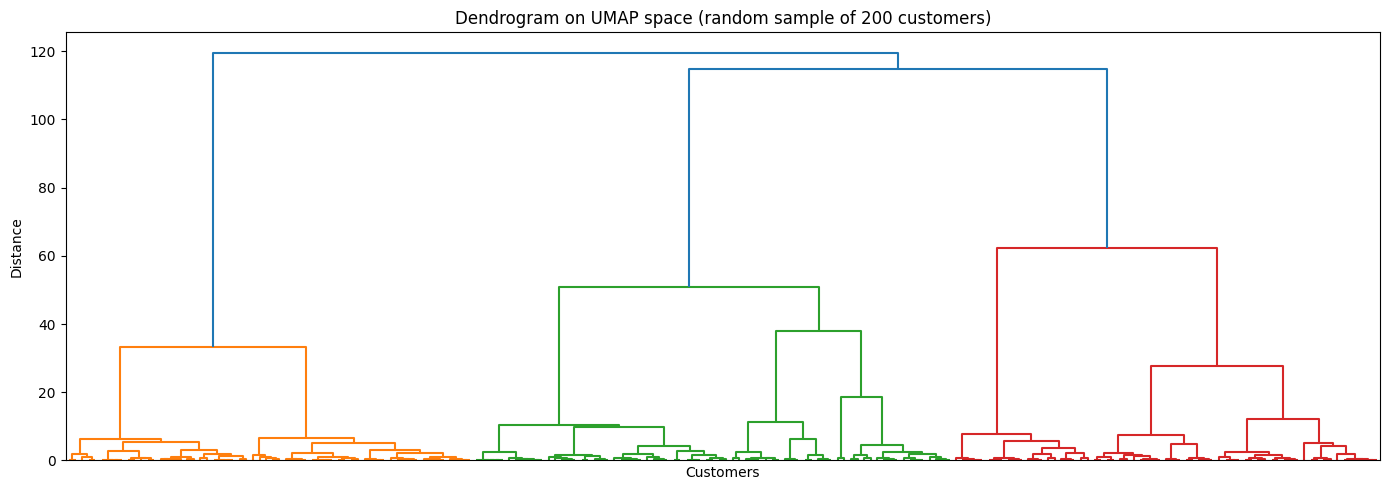

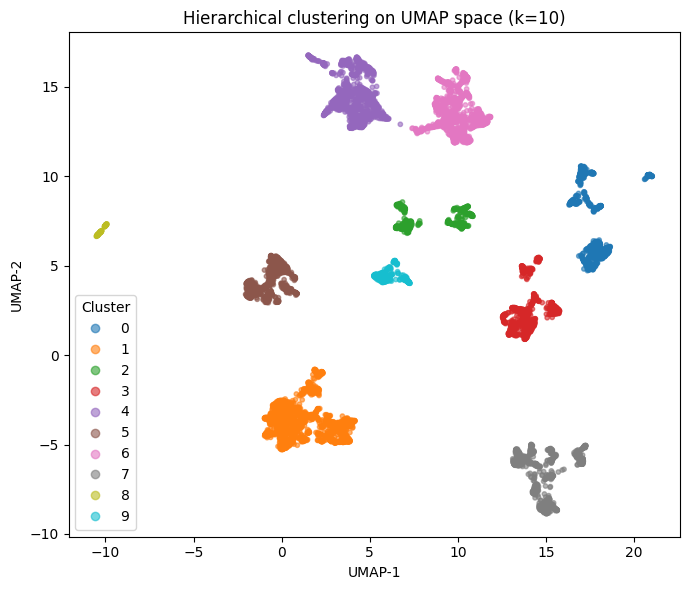


Saved: hierarchical_umap_clustered_output.csv


In [ ]:

# ════════════════════════════════════════════════════════════════════
# HIERARCHICAL CLUSTERING ON A UMAP-REDUCED SPACE, DYNAMIC K
#
# Difference from the earlier hierarchical script: instead of running
# Ward linkage directly on the ~13-dimensional scaled+target-encoded
# feature table, we first compress that table down to 2 dimensions
# with UMAP, and cluster IN THAT REDUCED SPACE. The idea: UMAP
# preserves local neighborhoods non-linearly, so points that are
# "really" close (even along a curved relationship Ward linkage's
# straight-line distance can't see) end up close together in the
# embedding — which can reveal tighter, more separable clusters than
# clustering directly on the raw scaled features.
#
# CAVEAT worth understanding: because we're now clustering INSIDE the
# UMAP space (not just visualizing it), UMAP's usual warning applies
# more strongly here — it distorts DISTANCES BETWEEN separated groups
# to preserve local neighborhoods. So clusters found here reflect
# "what UMAP decided was locally similar," which is a legitimate but
# different definition of similarity than clustering on the original
# scaled features directly. Worth comparing both, not treating this as
# strictly "better."
# ════════════════════════════════════════════════════════════════════
CSV_PATH       = 'layer2_xgb_predicted_subscribers.csv'
RANDOM_STATE   = 42
K_RANGE        = range(2, 11)
MIN_CLASS_SIZE = 150

NUMERIC_COLS = ['age', 'balance', 'day', 'campaign', 'duration']
CAT_COLS     = ['job', 'marital', 'education', 'default', 'housing',
                 'loan', 'contact', 'month']

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows (XGBoost-filtered: predicted subscribers only)")

Y_COL = 'y_enc' if 'y_enc' in df.columns else 'true_yes'
POOL_CONVERSION_RATE = df[Y_COL].mean() * 100
print(f"Overall pool conversion rate: {POOL_CONVERSION_RATE:.1f}%")

# ── STEP 1 — Transform 'balance', keep categoricals as strings ─────────
df['balance_log'] = np.sign(df['balance']) * np.log1p(np.abs(df['balance']))
for col in CAT_COLS:
    df[col] = df[col].astype(str)

# ── STEP 2 — Target-encode categoricals (numeric input needed) ─────────
NUMERIC_FOR_CLUSTER = ['age', 'balance_log', 'day', 'campaign', 'duration']
cat_encoded_cols = []
for col in CAT_COLS:
    te_col = f'{col}_te'
    rates = df.groupby(col)[Y_COL].mean()
    df[te_col] = df[col].map(rates)
    cat_encoded_cols.append(te_col)

FEATURE_COLS = NUMERIC_FOR_CLUSTER + cat_encoded_cols
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df[FEATURE_COLS]), columns=FEATURE_COLS)
print(f"Scaled feature table: {X_scaled.shape}")

# ── STEP 3 — Reduce to 2D with UMAP — THIS becomes the clustering space ──
reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
X_umap = reducer.fit_transform(X_scaled)
print(f"UMAP-reduced table: {X_umap.shape}")

# ── STEP 4 — Dynamic K via silhouette scan, ON THE UMAP SPACE ──────────
sil_scores = []
print(f"\nScanning k = {K_RANGE.start}..{K_RANGE.stop - 1} (Ward linkage, on UMAP space) ...")
for k in K_RANGE:
    hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hier.fit_predict(X_umap)
    sil = silhouette_score(X_umap, labels)
    sil_scores.append(sil)
    print(f"  k={k}  silhouette={sil:.3f}")

sil_table = pd.DataFrame({
    'k': list(K_RANGE),
    'silhouette': [round(v, 4) for v in sil_scores]
}).sort_values('silhouette', ascending=False).reset_index(drop=True)
print("\nFull silhouette comparison (sorted best → worst):")
print(sil_table)

K_BEST = list(K_RANGE)[int(np.argmax(sil_scores))]
if K_BEST == max(K_RANGE):
    print(f"\n  WARNING: best k ({K_BEST}) is at the EDGE of the tested range — consider widening K_RANGE.")
print(f"\nAuto-selected k = {K_BEST}  (silhouette = {max(sil_scores):.3f}, on UMAP space)")

# ── STEP 5 — Fit final hierarchical clustering on the UMAP embedding ───
hier_final = AgglomerativeClustering(n_clusters=K_BEST, linkage='ward')
df['cluster_hier_umap'] = hier_final.fit_predict(X_umap)

# ── STEP 6 — Profile the clusters ───────────────────────────────────────
print(f"\nCluster sizes (k={K_BEST}):")
print(df['cluster_hier_umap'].value_counts().sort_index())

print("\nAverage numeric values per cluster (raw, not transformed):")
print(df.groupby('cluster_hier_umap')[NUMERIC_COLS].mean().round(1))

print("\nMost common category per cluster (mode, raw category):")
print(df.groupby('cluster_hier_umap')[CAT_COLS].agg(lambda s: s.mode()[0]))

conversion = df.groupby('cluster_hier_umap').agg(
    customers=('cluster_hier_umap', 'size'),
    yes_count=(Y_COL, 'sum'),
    conversion_rate=(Y_COL, 'mean')
)
conversion['conversion_rate'] = (conversion['conversion_rate'] * 100).round(1)
conversion['reliable'] = conversion['customers'] >= MIN_CLASS_SIZE
conversion = conversion.sort_values('conversion_rate', ascending=False)
print(f"\nConversion rate per cluster (sorted best → worst, reliable = customers >= {MIN_CLASS_SIZE}):")
print(conversion)

# ── STEP 7 — Dendrogram (sample only — full dataset is unreadable) ──────
sample_idx = pd.DataFrame(X_umap).sample(n=min(200, len(X_umap)), random_state=RANDOM_STATE).index
linkage_matrix = linkage(X_umap[sample_idx], method='ward')
plt.figure(figsize=(14, 5))
dendrogram(linkage_matrix, no_labels=True)
plt.title(f'Dendrogram on UMAP space (random sample of {len(sample_idx)} customers)')
plt.xlabel('Customers'); plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# ── STEP 8 — Scatter plot (already 2D — this IS the clustering space) ──
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=df['cluster_hier_umap'], cmap='tab10', s=10, alpha=0.6)
plt.title(f'Hierarchical clustering on UMAP space (k={K_BEST})')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()

# ── STEP 9 — Save the clustered data ────────────────────────────────────
df.drop(columns=cat_encoded_cols).to_csv('hierarchical_umap_clustered_output.csv', index=False)
print("\nSaved: hierarchical_umap_clustered_output.csv")

## Extraction the data into CSV Format

In [ ]:

# ════════════════════════════════════════════════════════════════════
# POWER BI / TABLEAU EXPORT PREP
#
# Produces three clean, dashboard-ready tables from the final chosen
# segmentation (Hierarchical clustering on UMAP space). Doesn't re-run
# any model — just reshapes what's already been produced into a form
# that's easy to import and build visuals on top of.
#
#   1. dashboard_customer_level.csv  — one row per customer (fact table)
#   2. dashboard_segment_summary.csv — one row per segment (dimension/
#                                       summary table, joins to #1 on
#                                       cluster_hier_umap)
#   3. dashboard_funnel_summary.csv  — Layer 1 → Layer 2 → Layer 3
#                                       funnel counts, for the overview page
# ════════════════════════════════════════════════════════════════════
INPUT_PATH = 'hierarchical_umap_clustered_output.csv'
CLUSTER_COL = 'cluster_hier_umap'
MIN_CLASS_SIZE = 150

LAYER1_POOL_SIZE = 30777   # Layer 1 demographics pool

NUMERIC_COLS = ['age', 'balance', 'day', 'campaign', 'duration']
CAT_COLS     = ['job', 'marital', 'education', 'default', 'housing',
                 'loan', 'contact', 'month']

df = pd.read_csv(INPUT_PATH)
Y_COL = 'y_enc' if 'y_enc' in df.columns else 'true_yes'
layer2_pool_size = len(df)

# ── Persona names — EDIT these to match your own business language ─────
# Defaults below are derived from each cluster's dominant profile in the
# last run. Adjust freely; these are just a starting point so the
# dashboard shows readable names instead of "Cluster 3".
PERSONA_NAMES = {
    2: "Divorced Managers (March contacts)",
    8: "Credit-Default Blue-Collar (small sample)",
    0: "Retired - Telephone Outreach",
    6: "Married Managers, Higher Education (August)",
    7: "Blue-Collar with Personal Loan",
    3: "Blue-Collar - Unknown Contact Channel",
    9: "Divorced Managers - Homeowners",
    5: "Single Managers, Higher Education - Homeowners",
    4: "Technicians (February contacts)",
    1: "Blue-Collar Homeowners (largest group)",
}

# ── STEP 1 — Customer-level fact table ──────────────────────────────────
cluster_sizes = df[CLUSTER_COL].value_counts()
df['segment_reliable'] = df[CLUSTER_COL].map(cluster_sizes) >= MIN_CLASS_SIZE
df['segment_name'] = df[CLUSTER_COL].map(PERSONA_NAMES).fillna(df[CLUSTER_COL].astype(str))

customer_level_cols = ['segment_name', CLUSTER_COL, 'segment_reliable'] + NUMERIC_COLS + CAT_COLS + [Y_COL]
dashboard_customer_level = df[customer_level_cols].rename(columns={
    CLUSTER_COL: 'segment_id',
    Y_COL: 'converted'
})
dashboard_customer_level.to_csv('dashboard_customer_level.csv', index=False)
print(f"Saved: dashboard_customer_level.csv  ({len(dashboard_customer_level):,} rows)")

# ── STEP 2 — Segment summary table ───────────────────────────────────────
segment_summary = df.groupby(CLUSTER_COL).agg(
    customers=(CLUSTER_COL, 'size'),
    yes_count=(Y_COL, 'sum'),
    conversion_rate=(Y_COL, 'mean'),
    avg_age=('age', 'mean'),
    avg_balance=('balance', 'mean'),
    avg_campaign=('campaign', 'mean'),
    avg_duration=('duration', 'mean'),
).reset_index()

modes = df.groupby(CLUSTER_COL)[CAT_COLS].agg(lambda s: s.mode()[0]).reset_index()
segment_summary = segment_summary.merge(modes, on=CLUSTER_COL)

segment_summary['conversion_rate'] = (segment_summary['conversion_rate'] * 100).round(1)
segment_summary[['avg_age', 'avg_balance', 'avg_campaign', 'avg_duration']] = \
    segment_summary[['avg_age', 'avg_balance', 'avg_campaign', 'avg_duration']].round(1)
segment_summary['reliable'] = segment_summary['customers'] >= MIN_CLASS_SIZE
segment_summary['segment_name'] = segment_summary[CLUSTER_COL].map(PERSONA_NAMES)

segment_summary = segment_summary.sort_values('conversion_rate', ascending=False).reset_index(drop=True)
segment_summary['priority_rank'] = segment_summary.index + 1

segment_summary = segment_summary.rename(columns={CLUSTER_COL: 'segment_id'})
segment_summary.to_csv('dashboard_segment_summary.csv', index=False)
print(f"Saved: dashboard_segment_summary.csv  ({len(segment_summary)} segments)")

# ── STEP 3 — Funnel summary table ────────────────────────────────────────
reliable_customers = int(df['segment_reliable'].sum())

funnel = pd.DataFrame([
    {'stage': '1. Layer 1 - Demographics pool', 'customers': LAYER1_POOL_SIZE,
     'pct_of_previous': 100.0, 'note': 'Initial candidate pool'},
    {'stage': '2. Layer 2 - XGBoost predicted subscribers', 'customers': layer2_pool_size,
     'pct_of_previous': round(layer2_pool_size / LAYER1_POOL_SIZE * 100, 1),
     'note': f'{LAYER1_POOL_SIZE - layer2_pool_size:,} predicted-NOs removed - no call needed'},
    {'stage': '3. Layer 3 - Reliable segments (Hierarchical+UMAP)', 'customers': reliable_customers,
     'pct_of_previous': round(reliable_customers / layer2_pool_size * 100, 1),
     'note': 'Customers covered by segments large enough to trust (>=150 members)'},
])
funnel.to_csv('dashboard_funnel_summary.csv', index=False)
print(f"Saved: dashboard_funnel_summary.csv")
print(funnel.to_string(index=False))

Saved: dashboard_customer_level.csv  (8,589 rows)
Saved: dashboard_segment_summary.csv  (10 segments)
Saved: dashboard_funnel_summary.csv
                                             stage  customers  pct_of_previous                                                                note
                    1. Layer 1 - Demographics pool      30777            100.0                                              Initial candidate pool
        2. Layer 2 - XGBoost predicted subscribers       8589             27.9                       22,188 predicted-NOs removed - no call needed
3. Layer 3 - Reliable segments (Hierarchical+UMAP)       8475             98.7 Customers covered by segments large enough to trust (>=150 members)
